# DATA 300 — Final Project 


This project investigates the application of supervised machine learning to short-term equity volatility prediction across S&P 500 constituents. We evaluated 5 machine learning models (Lasso Regression, Ridge Regression, Gradient Boosting, Random Forest, and Decision Tree) against a naive lagged-volatility baseline using chronological cross-validation on daily data from 2015 to 2026. 

In [1]:
pip install yfinance lxml html5lib statsmodels

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Install necessary libraries 
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get data from yfinance
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
sp500_table = pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})[0]

tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
tickers.extend(['^GSPC', '^IRX'])

data = yf.download(tickers = tickers, start = '2015-01-01', interval = '1d', auto_adjust = True, progress = False)

data.head()

Đang tải dữ liệu cho 505 mã cổ phiếu + chỉ số...


Price           Close                                                   \
Ticker              A       AAPL       ABBV ABNB        ABT       ACGL   
Date                                                                     
2015-01-02  36.970375  24.214895  41.411907  NaN  36.009212  18.539352   
2015-01-05  36.277618  23.532722  40.632572  NaN  36.017227  18.428413   
2015-01-06  35.712479  23.534933  40.431458  NaN  35.608223  18.469618   
2015-01-07  36.186466  23.864946  42.065548  NaN  35.896935  18.577387   
2015-01-08  37.271164  24.781885  42.505505  NaN  36.634769  18.900694   

Price                                                   ...   Volume  \
Ticker            ACN       ADBE        ADI        ADM  ...      XEL   
Date                                                    ...            
2015-01-02  73.628235  72.339996  44.216049  37.381664  ...  2534900   
2015-01-05  72.385071  71.980003  43.411968  36.088177  ...  3107200   
2015-01-06  71.862923  70.529999  42.392952  35.376762  ...  4749600   
2015-01-07  73.371300  71.110001  42.838779  35.908524  ...  2833400   
2015-01-08  74.490143  72.919998  43.595081  35.383953  ...  2516800   

Price                                                                 \
Ticker           XOM      XYL XYZ      YUM      ZBH    ZBRA      ZTS   
Date                                                                   
2015-01-02  10220400   605900 NaN  2283466   936579  411800  1784200   
2015-01-05  18502400  1369900 NaN  4418651  2223873  420300  3112100   
2015-01-06  16670700  1333200 NaN  5004401  1835563  527500  3977200   
2015-01-07  13590700  1038600 NaN  4554134  1505860  467800  2481800   
2015-01-08  15487500   821800 NaN  4258268  1449004  324400  3121300   

Price                        
Ticker           ^GSPC ^IRX  
Date                         
2015-01-02  2708700000  0.0  
2015-01-05  3799120000  0.0  
2015-01-06  4460110000  0.0  
2015-01-07  3805480000  0.0  
2015-01-08  3934010000  0.0  

[5 rows x 2525 columns]

In [ ]:
dfs = []

for ticker in tickers:
    # Skip tickers not downloaded
    if ticker in data['Close'].columns:
        df_temp = pd.DataFrame()
        
        df_temp['close'] = data['Close'][ticker]
        df_temp['high']  = data['High'][ticker]
        df_temp['low']   = data['Low'][ticker]
        df_temp['volume'] = data['Volume'][ticker]
        
        df_temp['ticker'] = ticker
        dfs.append(df_temp)

# Check before concat (VERY IMPORTANT)
print("Number of valid tickers:", len(dfs))

# Combine all
df = pd.concat(dfs)
df = df.sort_index()

# Convert index → column
df = df.reset_index()
df = df.rename(columns={'index': 'Date'})

# Sort properly
df = df.sort_values(by=['Date', 'ticker'])

# Log return
df['return_1'] = np.log(
    df['close'] / df.groupby('ticker')['close'].shift(1)
)

df.head()

Number of valid tickers: 505


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Date,close,high,low,volume,ticker,return_1
161,2015-01-02,36.970375,37.653999,36.797188,1529200.0,A,NaN
432,2015-01-02,24.214895,24.682228,23.776355,212818400.0,AAPL,NaN
332,2015-01-02,41.411907,41.732444,41.129084,5086100.0,ABBV,NaN
296,2015-01-02,NaN,NaN,NaN,NaN,ABNB,NaN
380,2015-01-02,36.009212,36.450305,35.800694,3216600.0,ABT,NaN


In [184]:
df['vol_5'] = (
    df.groupby('ticker')['return_1']
    .rolling(window=5)
    .std()
    .reset_index(level=0, drop=True)
)

In [186]:
df['target_vol'] = df.groupby('ticker')['vol_5'].shift(-1)

In [188]:
for lag in [1, 2]:
    df[f'vol_lag_{lag}'] = df.groupby('ticker')['vol_5'].shift(lag)

In [190]:
for lag in [1, 2]:
    df[f'return_lag_{lag}'] = df.groupby('ticker')['return_1'].shift(lag)

In [192]:
df['return_10'] = df.groupby('ticker')['return_1'].rolling(10).sum().reset_index(0, drop=True)

df['vol_10'] = df.groupby('ticker')['return_1'].rolling(10).std().reset_index(0, drop=True)

In [193]:
df['r_pos'] = df['return_1'].clip(lower=0)
df['r_neg'] = df['return_1'].clip(upper=0)

df['r_pos_5'] = df.groupby('ticker')['r_pos'].rolling(5).sum().reset_index(0, drop=True)
df['r_neg_5'] = df.groupby('ticker')['r_neg'].rolling(5).sum().reset_index(0, drop=True)

In [196]:
df['ewma_vol'] = df.groupby('ticker')['return_1'].transform(lambda x: x.ewm(span=10).std())

In [198]:
df = df.dropna()

In [200]:
features = [
    'vol_lag_1','vol_lag_2',
    'return_lag_1','return_lag_2',
    'return_10',
    'vol_10',
    'r_pos_5','r_neg_5',
    'ewma_vol'
]

X = df[features]
y = df['target_vol']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Features shape: (1384208, 9)
Target shape: (1384208,)


,vol_lag_1,vol_lag_2,return_lag_1,return_lag_2,return_10,vol_10,r_pos_5,r_neg_5,ewma_vol
5154,0.007492,0.018495,-0.027250,-0.012466,-0.058639,0.017119,0.006295,-0.065672,0.016374
5396,0.016151,0.022731,-0.027515,-0.003818,-0.031026,0.020736,0.008839,-0.064083,0.018700
5499,0.015503,0.018729,-0.012797,0.004878,-0.013222,0.022430,0.030776,-0.042328,0.022274
5087,0.009139,0.015068,-0.007480,-0.007425,-0.003894,0.012081,0.020584,-0.031137,0.012183
5548,0.005471,0.010166,0.003728,-0.004405,0.012910,0.007418,0.009820,-0.007454,0.006353


### Part A: Exploratory Data Analysis

The dataset is structured as a supervised time-series regression dataset. Each row represents one ticker on one trading day, and the target variable, `target_vol`, is the next-day value of 5-day rolling volatility. Therefore, the project is framed as a short-term volatility forecasting problem rather than a next-day direction classification problem.

The EDA confirms that the target variable is right-skewed, which is expected because volatility is nonnegative and tends to spike during periods of market stress. The time-series plots show volatility clustering: calm periods are followed by calm periods, while high-volatility periods tend to persist for several days. This supports the use of lagged volatility variables such as `vol_lag_1`, `vol_lag_2`, `vol_lag_5`, `vol_10`, `vol_20`, and `ewma_vol`.

The correlation analysis shows that recent volatility variables are expected to be among the strongest predictors of future volatility. This is consistent with the financial literature, which emphasizes that volatility is persistent and autoregressive. The signed return variables, especially negative-return measures such as `r_neg_5` and `r_neg_10`, are also important because downside movements are often associated with higher future volatility.

Because this is financial time-series data, the train/test split must be chronological rather than random. A random split would allow future observations to influence model training and create look-ahead bias. The EDA therefore prepares the dataset for a time-aware modeling workflow in later sections.

In [202]:
# 1. Basic dataset structure
print("Dataset shape:", df.shape)
print("\nDate range:")
print(df['Date'].min(), "to", df['Date'].max())

print("\nNumber of unique tickers:", df['ticker'].nunique())

print("\nColumns:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Dataset shape: (1384208, 20)

Date range:
2015-01-16 00:00:00 to 2026-04-23 00:00:00

Number of unique tickers: 505

Columns:
['Date', 'close', 'high', 'low', 'volume', 'ticker', 'return_1', 'vol_5', 'target_vol', 'vol_lag_1', 'vol_lag_2', 'return_lag_1', 'return_lag_2', 'return_10', 'vol_10', 'r_pos', 'r_neg', 'r_pos_5', 'r_neg_5', 'ewma_vol']


,Date,close,high,low,volume,ticker,return_1,vol_5,target_vol,vol_lag_1,vol_lag_2,return_lag_1,return_lag_2,return_10,vol_10,r_pos,r_neg,r_pos_5,r_neg_5,ewma_vol
5154,2015-01-16,34.864803,35.056217,34.418168,3004000.0,A,0.006295,0.011955,0.012055,0.007492,0.018495,-0.027250,-0.012466,-0.058639,0.017119,0.006295,0.0000,0.006295,-0.065672,0.016374
5396,2015-01-16,23.475130,23.827291,23.300157,314053200.0,AAPL,-0.007800,0.015188,0.019702,0.016151,0.022731,-0.027515,-0.003818,-0.031026,0.020736,0.000000,-0.0078,0.008839,-0.064083,0.018700
5499,2015-01-16,40.867954,40.918613,39.664837,8106000.0,ABBV,0.025898,0.020530,0.021463,0.015503,0.018729,-0.012797,0.004878,-0.013222,0.022430,0.025898,0.0000,0.030776,-0.042328,0.022274
5087,2015-01-16,35.869282,35.917654,35.248482,4564200.0,ABT,0.012212,0.011953,0.010436,0.009139,0.015068,-0.007480,-0.007425,-0.003894,0.012081,0.012212,0.0000,0.020584,-0.031137,0.012183
5548,2015-01-16,18.780247,18.868996,18.694666,1775100.0,ACGL,0.002197,0.003920,0.005551,0.005471,0.010166,0.003728,-0.004405,0.012910,0.007418,0.002197,0.0000,0.009820,-0.007454,0.006353


,Date,close,high,low,volume,ticker,return_1,vol_5,target_vol,vol_lag_1,vol_lag_2,return_lag_1,return_lag_2,return_10,vol_10,r_pos,r_neg,r_pos_5,r_neg_5,ewma_vol
1435558,2026-04-23,92.440002,93.519997,91.419998,1.843800e+06,ZBH,-0.006470,0.014703,0.014733,0.015450,0.017574,0.003769,-0.029656,-0.006362,0.016065,0.0,-0.006470,0.011127,-0.036126,0.014743
1435554,2026-04-23,226.869995,231.860001,221.649994,8.507000e+05,ZBRA,-0.018473,0.015451,0.015067,0.015538,0.007107,-0.023816,-0.002658,0.016891,0.014102,0.0,-0.018473,0.018115,-0.044948,0.017759
1435562,2026-04-23,116.059998,117.599998,114.949997,4.532800e+06,ZTS,-0.012501,0.024170,0.018435,0.024341,0.024343,-0.005600,-0.037696,-0.028961,0.019141,0.0,-0.012501,0.034786,-0.055798,0.018864
1435565,2026-04-23,7108.399902,7147.779785,7046.549805,5.307260e+09,^GSPC,-0.004141,0.008615,0.007562,0.007934,0.007440,0.010406,-0.006368,0.040735,0.007148,0.0,-0.004141,0.022374,-0.012887,0.008508
1435564,2026-04-23,3.595000,3.595000,3.585000,0.000000e+00,^IRX,0.000000,0.001144,0.000373,0.001067,0.001150,-0.000834,0.000000,0.001949,0.001650,0.0,0.000000,0.000000,-0.004164,0.001642


In [204]:
# 3. Summary statistics for all model variables
eda_cols = features + ['target_vol']

summary_stats = df[eda_cols].describe().T
summary_stats['skew'] = df[eda_cols].skew()
summary_stats['kurtosis'] = df[eda_cols].kurtosis()

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
vol_lag_1,1384208.0,0.016675,0.016375,0.000000,0.008778,0.013218,0.020045,1.934088,22.203952,1480.547901
vol_lag_2,1384208.0,0.016675,0.016380,0.000000,0.008778,0.013218,0.020044,1.934088,22.195024,1478.931930
return_lag_1,1384208.0,0.000463,0.023013,-2.871680,-0.008386,0.000778,0.009800,2.538974,-2.355121,730.638321
return_lag_2,1384208.0,0.000461,0.023011,-2.871680,-0.008387,0.000777,0.009798,2.538974,-2.354618,730.836290
return_10,1384208.0,0.004603,0.066609,-2.995732,-0.025335,0.006681,0.037258,3.191847,-0.790118,57.244356
vol_10,1384208.0,0.017510,0.015296,0.000000,0.010237,0.014363,0.020626,1.398264,21.281014,1193.863670
r_pos_5,1384208.0,0.035298,0.037139,0.000000,0.014939,0.027222,0.045120,3.178054,12.608919,561.004756
r_neg_5,1384208.0,-0.032983,0.041230,-4.428168,-0.042340,-0.023345,-0.011180,0.000000,-14.432828,743.425084
ewma_vol,1384208.0,0.017719,0.015028,0.000013,0.010642,0.014641,0.020697,1.675835,22.032236,1273.492265
target_vol,1384208.0,0.016680,0.016429,0.000000,0.008782,0.013223,0.020051,1.934088,22.746521,1541.122360


In [206]:
target = ['target_vol']

summary_stats = df[target].describe().applymap(lambda x: f"{x:.4f}")

display(summary_stats)

/var/folders/9c/0j16jmp51933bz_d44fw4vfm0000gn/T/ipykernel_88886/1960289644.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary_stats = df[target].describe().applymap(lambda x: f"{x:.4f}")


,target_vol
count,1384208.0000
mean,0.0167
std,0.0164
min,0.0000
25%,0.0088
50%,0.0132
75%,0.0201
max,1.9341


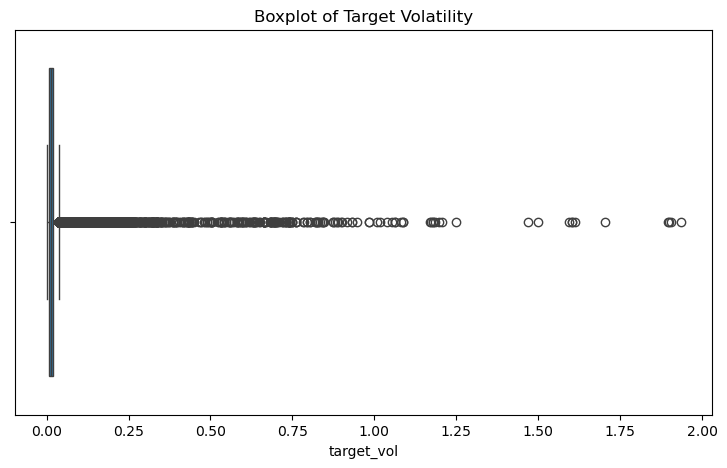

In [208]:
# 4. Target variable distribution
plt.figure(figsize=(9, 5))
sns.boxplot(x=df['target_vol'])
plt.title("Boxplot of Target Volatility")
plt.xlabel("target_vol")
plt.show()

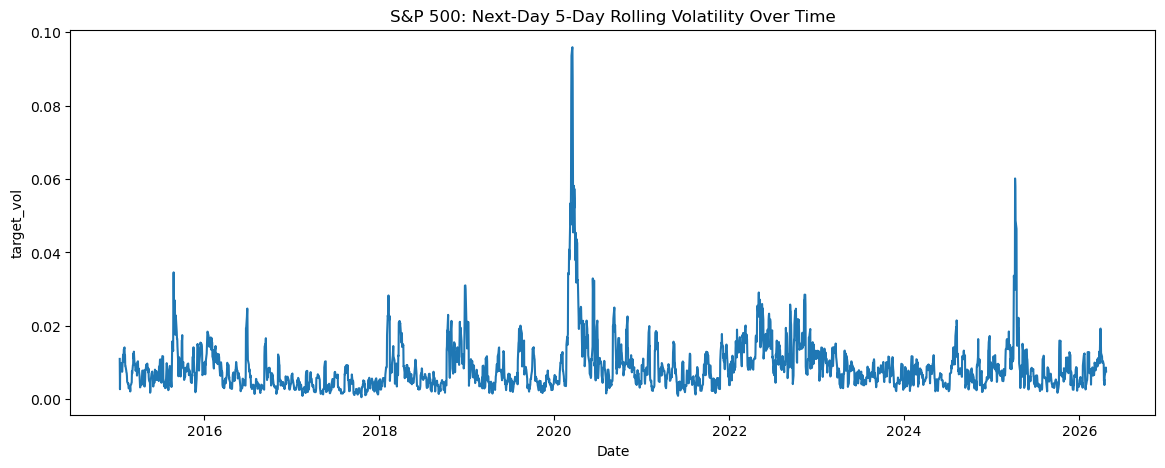

In [33]:
# 5. Target volatility over time for market index only
# ^GSPC = S&P 500 Index
gspc = df[df['ticker'] == '^GSPC'].copy()

plt.figure(figsize=(14, 5))
plt.plot(gspc['Date'], gspc['target_vol'])
plt.title("S&P 500: Next-Day 5-Day Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("target_vol")
plt.show()

In [210]:
# 8. Correlation with target volatility
corr_with_target = (
    df[eda_cols]
    .corr()['target_vol']
    .sort_values(ascending=False)
)

display(corr_with_target)

target_vol      1.000000
ewma_vol        0.888912
vol_10          0.828676
vol_lag_1       0.826642
vol_lag_2       0.742899
r_pos_5         0.661402
return_lag_1   -0.048060
return_lag_2   -0.062615
return_10      -0.171904
r_neg_5        -0.756223
Name: target_vol, dtype: float64

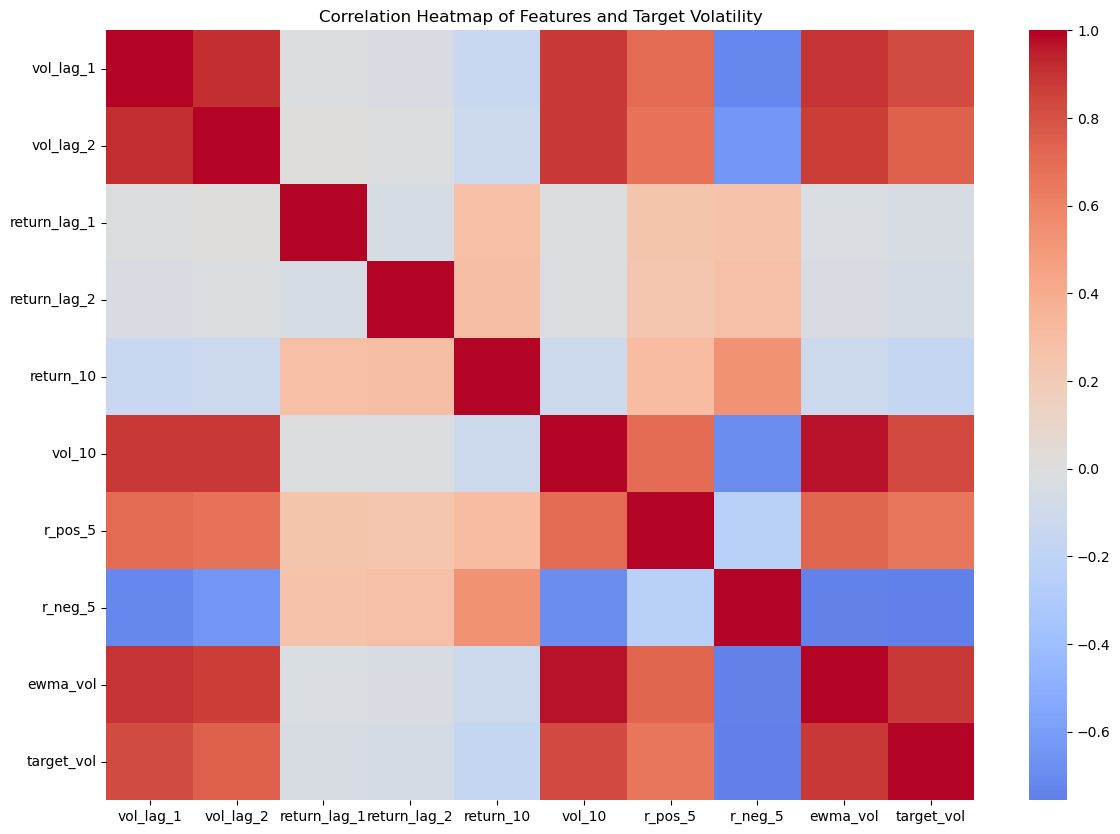

In [212]:
# 9. Correlation heatmap among model variables
plt.figure(figsize=(14, 10))
corr_matrix = df[eda_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Features and Target Volatility")
plt.show()

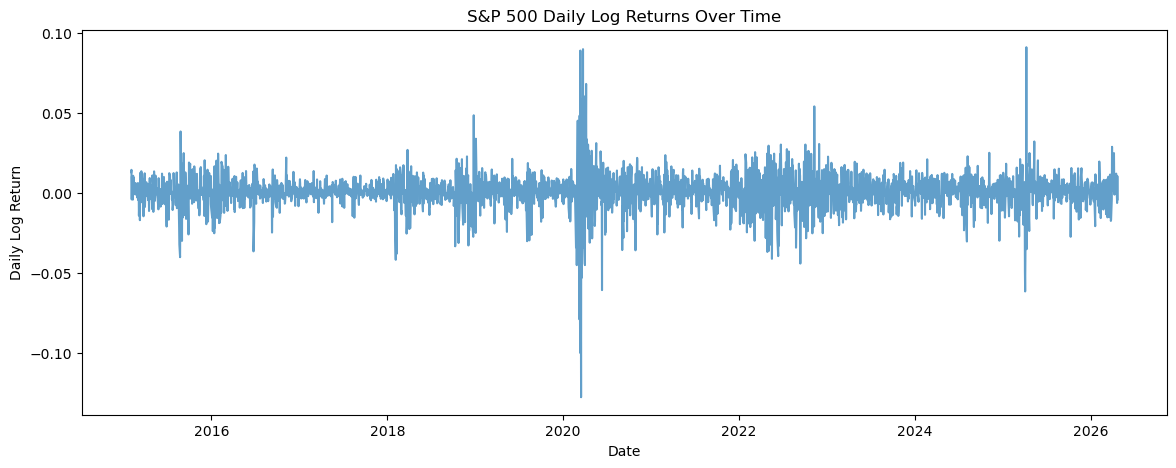

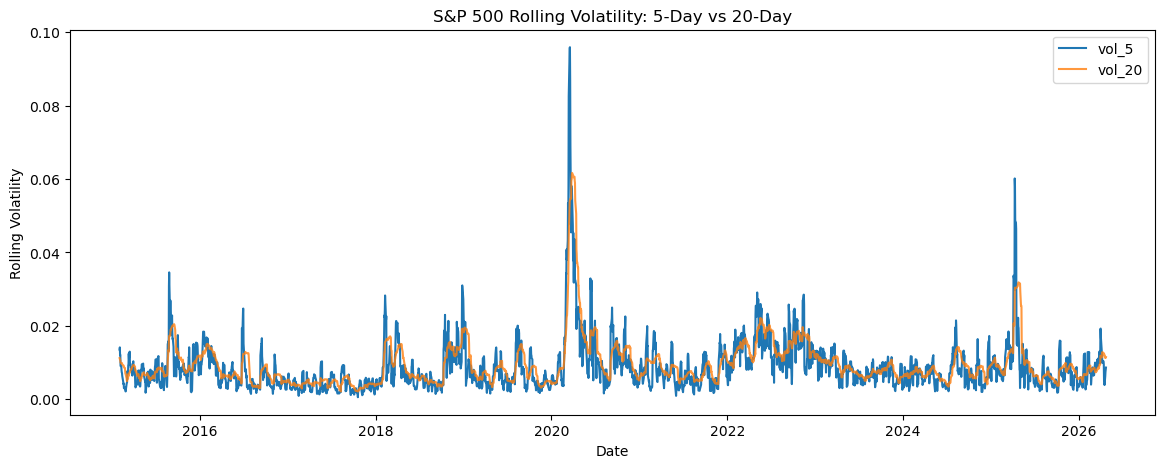

In [48]:
# 11. Examine volatility clustering for S&P 500
plt.figure(figsize=(14, 5))
plt.plot(gspc['Date'], gspc['return_1'], alpha=0.7)
plt.title("S&P 500 Daily Log Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Log Return")
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(gspc['Date'], gspc['vol_5'], label='vol_5')
plt.plot(gspc['Date'], gspc['vol_20'], label='vol_20', alpha=0.8)
plt.title("S&P 500 Rolling Volatility: 5-Day vs 20-Day")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.show()

In [214]:
# 13. Time-aware train/test split preview
# This avoids random splitting, which would leak future market information into the training process.

df_sorted = df.sort_values('Date').copy()

split_date = df_sorted['Date'].quantile(0.80)

train_df = df_sorted[df_sorted['Date'] <= split_date]
test_df = df_sorted[df_sorted['Date'] > split_date]

print("Split date:", split_date)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:", train_df['Date'].min(), "to", train_df['Date'].max())
print("Test date range:", test_df['Date'].min(), "to", test_df['Date'].max())

Split date: 2024-02-13 00:00:00
Train shape: (1107748, 20)
Test shape: (276460, 20)

Train date range: 2015-01-16 00:00:00 to 2024-02-13 00:00:00
Test date range: 2024-02-14 00:00:00 to 2026-04-23 00:00:00


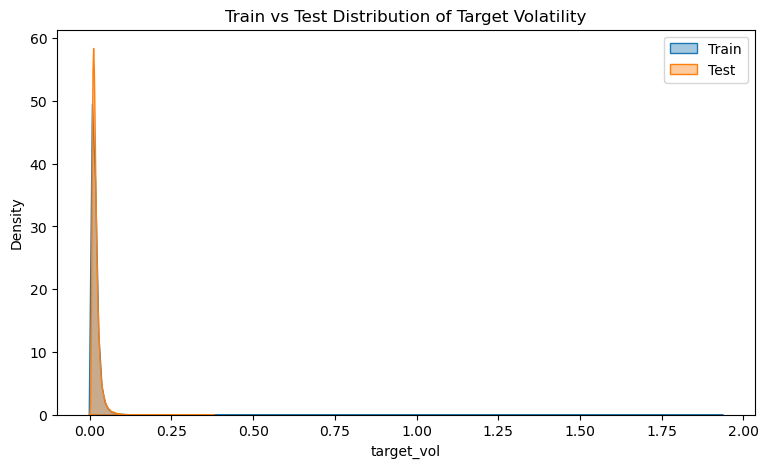

In [91]:
# 14. Compare target distribution in train vs test
plt.figure(figsize=(9, 5))
sns.kdeplot(train_df['target_vol'], label='Train', fill=True, alpha=0.4)
sns.kdeplot(test_df['target_vol'], label='Test', fill=True, alpha=0.4)
plt.title("Train vs Test Distribution of Target Volatility")
plt.xlabel("target_vol")
plt.ylabel("Density")
plt.legend()
plt.show()

### Part B: Model Code

Because the response variable `target_vol` is continuous, this project is modeled as a supervised regression problem rather than a classification problem. The goal is to predict next-day 5-day rolling volatility using variables that are observable before the forecast date.

I compare several models. The baseline model predicts future volatility using `vol_lag_1`, which is appropriate because volatility is persistent and tends to cluster over time. Linear regression provides an interpretable benchmark. Ridge and Lasso regression extend the linear model by adding regularization, which is useful because the EDA showed strong correlations among volatility features. Random Forest and Gradient Boosting are included because they can capture nonlinear relationships and interactions among lagged volatility, returns, and signed return-pressure variables.

The model comparison uses `TimeSeriesSplit` instead of random cross-validation. This is important because financial data are ordered over time, and random splitting would create look-ahead bias by allowing future observations to influence model training. The main evaluation metric in this section is cross-validated RMSE because the target is a continuous volatility measure and larger forecasting errors should be penalized more heavily.

In [216]:
# ============================================================
# PART B: Model Code
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# -----------------------------
# 1. Evaluation metric functions
# -----------------------------

def rmse(y_true, y_pred):
    """
    Root Mean Squared Error.
    Lower RMSE means better prediction accuracy.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def regression_metrics(y_true, y_pred):
    """
    Return the main regression evaluation metrics.
    """
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [218]:
# -----------------------------
# 2. Baseline model
# -----------------------------

class HistoricalVolatilityBaseline:
    """
    Baseline volatility model.

    This model predicts tomorrow's target volatility using today's 5-day volatility.
    In this project, vol_lag_1 is the most natural naive benchmark because volatility
    is persistent and autoregressive.
    """
    
    def fit(self, X, y=None):
        return self
    
    def predict(self, X):
        X = pd.DataFrame(X)
        
        if 'vol_lag_1' in X.columns:
            return X['vol_lag_1'].values
        
        # fallback if X is passed as a NumPy array
        vol_lag_1_index = features.index('vol_lag_1')
        return X.iloc[:, vol_lag_1_index].values

In [220]:
# -----------------------------
# 3. Define candidate models
# -----------------------------

models = {
    "Baseline: vol_lag_1": HistoricalVolatilityBaseline(),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.00001, max_iter=10000))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=20,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=20,
        random_state=42
    )
}

In [222]:
# -----------------------------
# 4. Time-series cross-validation function
# -----------------------------

def time_series_cv_results(models, X, y, n_splits=5):
    """
    Evaluate models using TimeSeriesSplit.

    This avoids random cross-validation because random splits would allow future
    market observations to influence model training.
    """
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    for name, model in models.items():
        fold_rmse = []
        fold_mae = []
        fold_r2 = []

        for train_idx, val_idx in tscv.split(X):
            X_train_fold = X.iloc[train_idx]
            X_val_fold = X.iloc[val_idx]
            y_train_fold = y.iloc[train_idx]
            y_val_fold = y.iloc[val_idx]

            model.fit(X_train_fold, y_train_fold)
            y_val_pred = model.predict(X_val_fold)

            fold_rmse.append(rmse(y_val_fold, y_val_pred))
            fold_mae.append(mean_absolute_error(y_val_fold, y_val_pred))
            fold_r2.append(r2_score(y_val_fold, y_val_pred))

        results.append({
            "Model": name,
            "CV RMSE Mean": np.mean(fold_rmse),
            "CV RMSE Std": np.std(fold_rmse),
            "CV MAE Mean": np.mean(fold_mae),
            "CV R2 Mean": np.mean(fold_r2)
        })
    results_df = pd.DataFrame(results).sort_values("CV RMSE Mean").reset_index(drop=True)
    return results_df

In [224]:
# -----------------------------
# 5. Run Part B model comparison
# -----------------------------

# Use all engineered variables from Part A
X_model = df[features].copy()
y_model = df['target_vol'].copy()

cv_results_df = time_series_cv_results(
    models=models,
    X=X_model,
    y=y_model,
    n_splits=5
)

display(cv_results_df)

,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV R2 Mean
0,Lasso Regression,0.006177,0.000998,0.003548,0.786247
1,Ridge Regression,0.006180,0.001000,0.003548,0.786109
2,Gradient Boosting,0.006287,0.001018,0.003632,0.778970
3,Random Forest,0.006328,0.001158,0.003638,0.779584
4,Decision Tree,0.007477,0.001399,0.004412,0.692583
5,Baseline: vol_lag_1,0.009095,0.001357,0.005151,0.533013


In [226]:
# -----------------------------
# 6. Select best model from cross-validation
# -----------------------------

best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on CV RMSE:", best_model_name)
display(cv_results_df.head())

Best model based on CV RMSE: Lasso Regression


,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV R2 Mean
0,Lasso Regression,0.006177,0.000998,0.003548,0.786247
1,Ridge Regression,0.006180,0.001000,0.003548,0.786109
2,Gradient Boosting,0.006287,0.001018,0.003632,0.778970
3,Random Forest,0.006328,0.001158,0.003638,0.779584
4,Decision Tree,0.007477,0.001399,0.004412,0.692583


In [235]:
# ============================================================
# PART C: Final Model Evaluation
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Create chronological train/test split
# ------------------------------------------------------------

# Sort by date to avoid look-ahead bias
df_model = df.sort_values("Date").copy()

X = df_model[features].copy()
y = df_model["target_vol"].copy()

split_idx = int(len(df_model) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training period:", df_model["Date"].iloc[:split_idx].min(), "to", df_model["Date"].iloc[:split_idx].max())
print("Testing period :", df_model["Date"].iloc[split_idx:].min(), "to", df_model["Date"].iloc[split_idx:].max())

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Training period: 2015-01-16 00:00:00 to 2024-02-13 00:00:00
Testing period : 2024-02-13 00:00:00 to 2026-04-23 00:00:00
X_train: (1107366, 9)
X_test : (276842, 9)
y_train: (1107366,)
y_test : (276842,)


In [237]:
# ------------------------------------------------------------
# 2. Fit all candidate models on training set
# ------------------------------------------------------------

final_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    final_predictions[name] = model.predict(X_test)

In [238]:
# ------------------------------------------------------------
# 3. Define evaluation function
# ------------------------------------------------------------

def evaluate_final_model(name, y_true, y_pred):
    """
    Evaluate regression model performance using standard forecasting metrics.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse_value = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse_value,
        "MAE": mae,
        "R2": r2
    }

In [239]:
# ------------------------------------------------------------
# 4. Final test-set comparison
# ------------------------------------------------------------

final_results = []

for name, pred in final_predictions.items():
    final_results.append(evaluate_final_model(name, y_test, pred))

final_results_df = pd.DataFrame(final_results)
final_results_df = final_results_df.sort_values("RMSE").reset_index(drop=True)

display(final_results_df)

best_final_model_name = final_results_df.iloc[0]["Model"]
best_final_pred = final_predictions[best_final_model_name]

print("Best final model based on test RMSE:", best_final_model_name)

,Model,MSE,RMSE,MAE,R2
0,Lasso Regression,0.000043,0.006533,0.003749,0.755854
1,Ridge Regression,0.000043,0.006536,0.003749,0.755668
2,Random Forest,0.000043,0.006539,0.003784,0.755426
3,Gradient Boosting,0.000043,0.006581,0.003795,0.752290
4,Decision Tree,0.000059,0.007710,0.004647,0.660019
5,Baseline: vol_lag_1,0.000096,0.009779,0.005418,0.453051


Best final model based on test RMSE: Lasso Regression


In [245]:
# ------------------------------------------------------------
# 5. Compare cross-validation and final test results
# ------------------------------------------------------------

comparison_table = cv_results_df.merge(
    final_results_df,
    on="Model",
    how="inner"
)

comparison_table = comparison_table[
    ["Model", "CV RMSE Mean", "CV MAE Mean", "CV R2 Mean", "RMSE", "MAE", "R2"]
].sort_values("RMSE")

display(comparison_table)

,Model,CV RMSE Mean,CV MAE Mean,CV R2 Mean,RMSE,MAE,R2
0,Lasso Regression,0.006177,0.003548,0.786247,0.006533,0.003749,0.755854
1,Ridge Regression,0.006180,0.003548,0.786109,0.006536,0.003749,0.755668
3,Random Forest,0.006328,0.003638,0.779584,0.006539,0.003784,0.755426
2,Gradient Boosting,0.006287,0.003632,0.778970,0.006581,0.003795,0.752290
4,Decision Tree,0.007477,0.004412,0.692583,0.007710,0.004647,0.660019
5,Baseline: vol_lag_1,0.009095,0.005151,0.533013,0.009779,0.005418,0.453051


In [317]:
# ------------------------------------------------------------
# 5b. Spike-aware evaluation (extension of final evaluation)
# ------------------------------------------------------------

def asymmetric_rmse(y_true, y_pred, penalty=2.0):
    """Penalizes underestimation of volatility spikes more heavily."""
    errors = y_true - y_pred
    weights = np.where(errors > 0, penalty, 1.0)
    return np.sqrt(np.mean(weights * errors**2))

def spike_rmse(y_true, y_pred, threshold=0.03):
    """RMSE on high volatility days only."""
    mask = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

spike_results = []
for name, pred in final_predictions.items():
    spike_results.append({
        "Model":           name,
        "RMSE":            rmse(y_test, pred),                        # same as before
        "Asymmetric RMSE": asymmetric_rmse(y_test.values, pred),      # penalizes missed spikes
        "Spike RMSE":      spike_rmse(y_test.values, pred, threshold=0.03)  # spikes only
    })

spike_df = pd.DataFrame(spike_results).sort_values("Spike RMSE").reset_index(drop=True)
display(spike_df)

,Model,RMSE,Asymmetric RMSE,Spike RMSE
0,Ridge Regression,0.006536,0.008349,0.015017
1,Lasso Regression,0.006533,0.008349,0.015029
2,Random Forest,0.006539,0.008392,0.015219
3,Gradient Boosting,0.006581,0.008492,0.015508
4,Decision Tree,0.007710,0.009658,0.016975
5,Baseline: vol_lag_1,0.009779,0.012033,0.020990


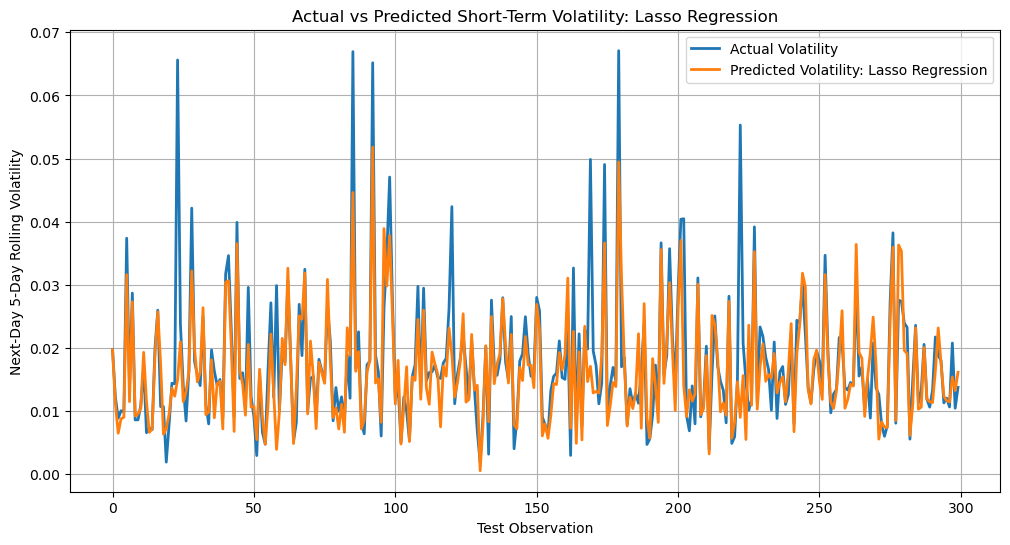

In [313]:
# ------------------------------------------------------------
# 6. Actual vs predicted plot for best model
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(y_test.values[:300], label="Actual Volatility", linewidth=2)
plt.plot(best_final_pred[:300], label=f"Predicted Volatility: {best_final_model_name}", linewidth=2)

plt.title(f"Actual vs Predicted Short-Term Volatility: {best_final_model_name}")
plt.xlabel("Test Observation")
plt.ylabel("Next-Day 5-Day Rolling Volatility")
plt.legend()
plt.grid(True)
plt.show()

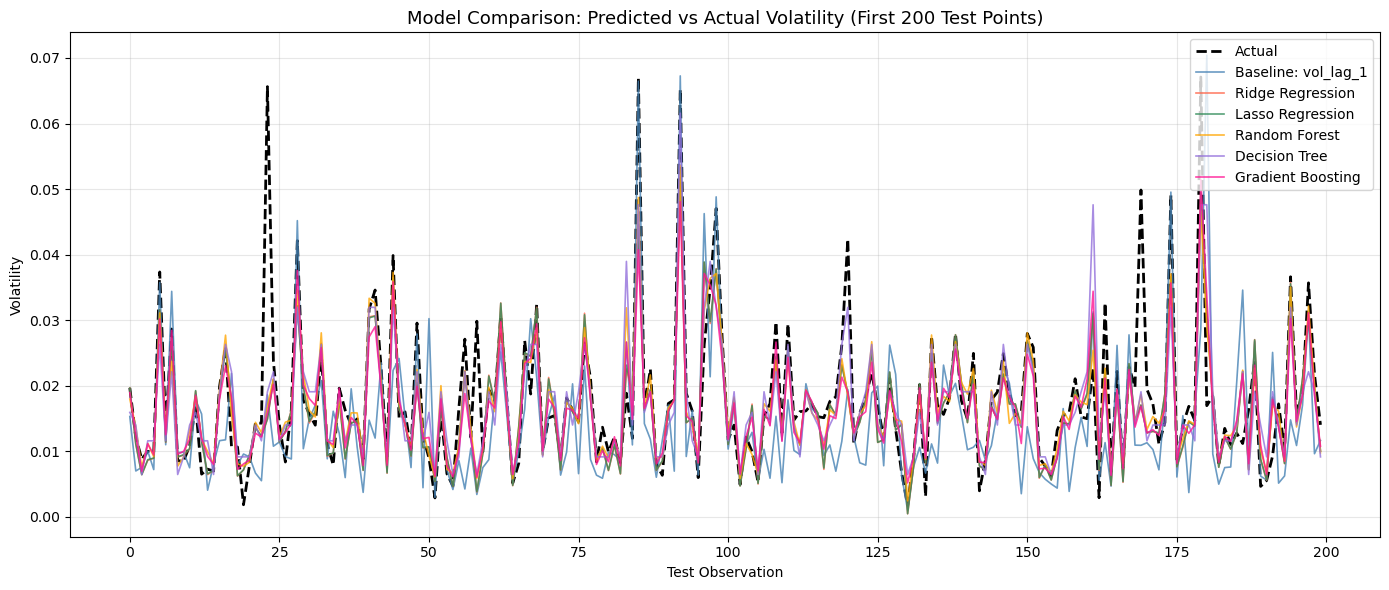

In [253]:
# ------------------------------------------------------------
# Overlay: All model predictions vs Actual
# ------------------------------------------------------------

n = 200  # number of points to show
plt.figure(figsize=(14, 6))

# Actual
plt.plot(y_test.values[:n], label="Actual", linewidth=2, color="black", linestyle="--")

# One color per model
colors = ["steelblue", "tomato", "seagreen", "orange", "mediumpurple", "deeppink"]

for (name, pred), color in zip(final_predictions.items(), colors):
    plt.plot(pred[:n], label=name, linewidth=1.2, alpha=0.8, color=color)

plt.title("Model Comparison: Predicted vs Actual Volatility (First 200 Test Points)", fontsize=13)
plt.xlabel("Test Observation")
plt.ylabel("Volatility")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("all_models_comparison.png", dpi=300)
plt.show()

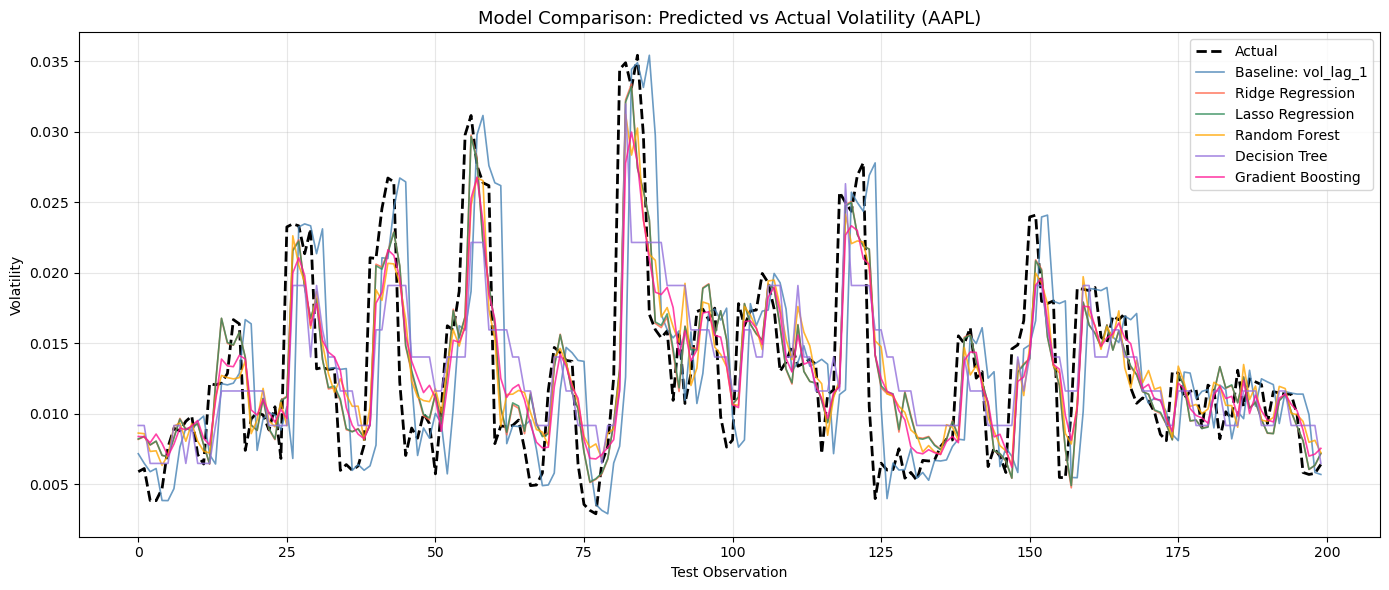

In [255]:
# Filter to one stock before plotting
ticker = "AAPL"
mask = df_model["ticker"].iloc[split_idx:].reset_index(drop=True).values == ticker
y_test_one = y_test.values[mask][:200]

colors = ["steelblue", "tomato", "seagreen", "orange", "mediumpurple", "deeppink"]

plt.figure(figsize=(14, 6))
plt.plot(y_test_one, label="Actual", linewidth=2, color="black", linestyle="--")

for (name, pred), color in zip(final_predictions.items(), colors):
    plt.plot(pred[mask][:200], label=name, linewidth=1.2, alpha=0.8, color=color)

plt.title(f"Model Comparison: Predicted vs Actual Volatility ({ticker})", fontsize=13)
plt.xlabel("Test Observation")
plt.ylabel("Volatility")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"model_comparison_{ticker}.png", dpi=300)
plt.show()

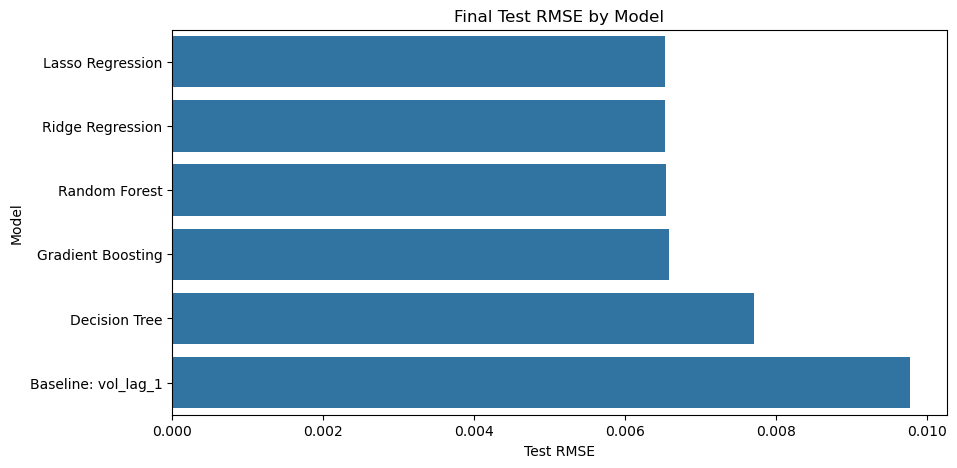

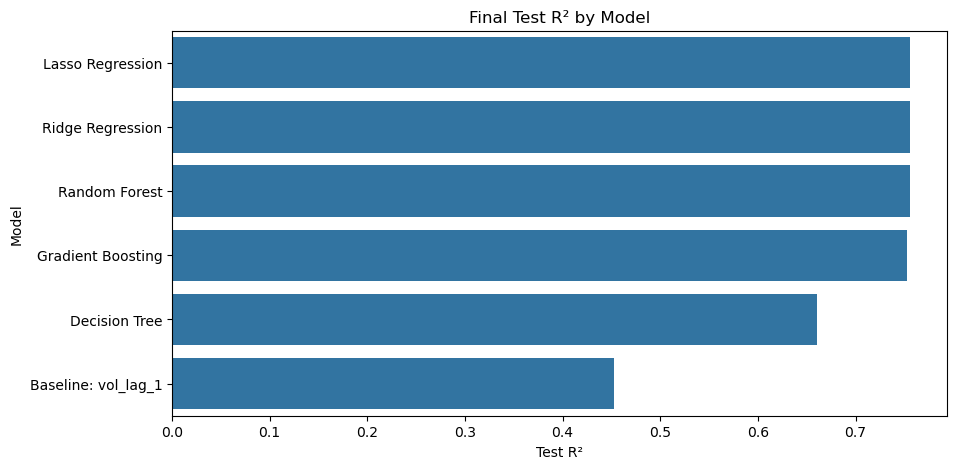

In [257]:
# ------------------------------------------------------------
# 8. Model ranking visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="RMSE", y="Model")
plt.title("Final Test RMSE by Model")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="R2", y="Model")
plt.title("Final Test R² by Model")
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.show()

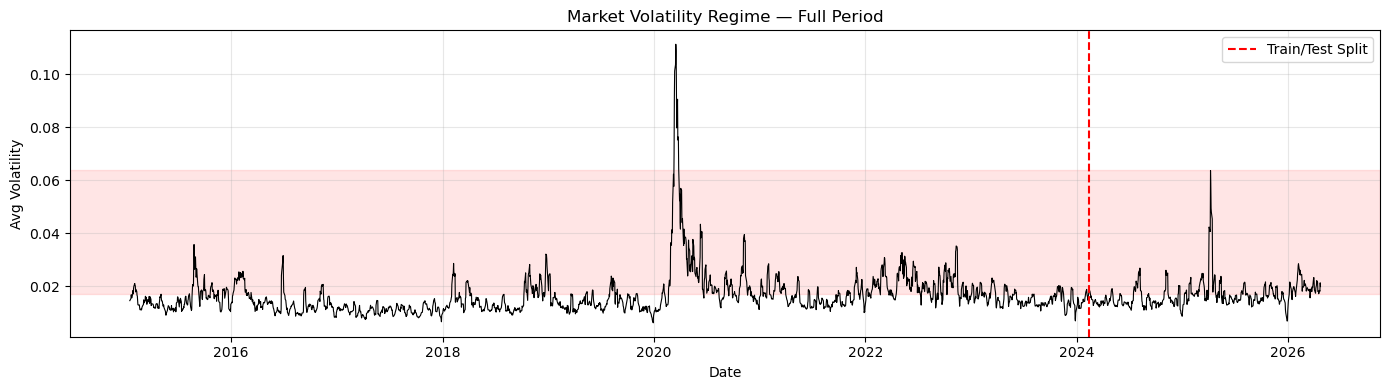

Train avg vol: 0.0165
Test avg vol : 0.0171


In [259]:
import matplotlib.pyplot as plt

# Plot realized volatility over full period to visualize regimes
daily_vol = df.groupby("Date")["target_vol"].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_vol, color="black", linewidth=0.8)
plt.axvline(pd.Timestamp("2024-02-14"), color="red", linestyle="--", label="Train/Test Split")
plt.axhspan(daily_vol[daily_vol.index >= "2024-02-14"].mean(),
            daily_vol[daily_vol.index >= "2024-02-14"].max(),
            alpha=0.1, color="red")
plt.title("Market Volatility Regime — Full Period")
plt.xlabel("Date")
plt.ylabel("Avg Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print average volatility by period
print("Train avg vol:", daily_vol[daily_vol.index < "2024-02-14"].mean().round(4))
print("Test avg vol :", daily_vol[daily_vol.index >= "2024-02-14"].mean().round(4))

,Feature,Coefficient (abs)
0,ewma_vol,0.015065
1,vol_10,0.006158
2,r_neg_5,0.005391
3,r_pos_5,0.004001
4,vol_lag_2,0.002473
5,vol_lag_1,0.001565
6,return_10,0.000367
7,return_lag_1,0.000043
8,return_lag_2,0.000000


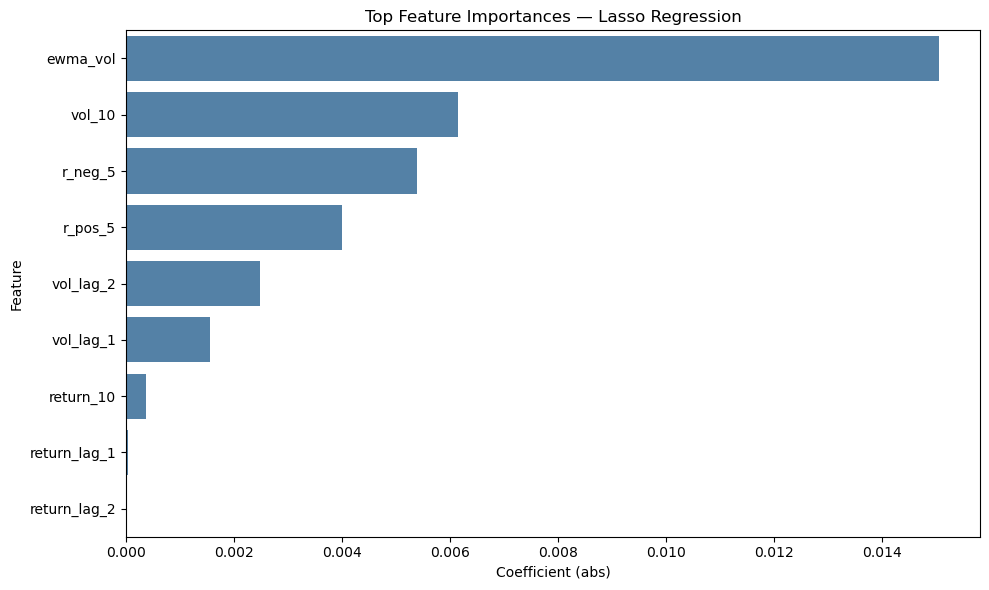

In [267]:
best_model = models[best_final_model_name]
best_model.fit(X_train, y_train)

# Extract actual model from pipeline
if hasattr(best_model, "named_steps"):
    actual_model = list(best_model.named_steps.values())[-1]  # last step = model
else:
    actual_model = best_model

# Get importance
if hasattr(actual_model, "feature_importances_"):
    importance = actual_model.feature_importances_
    importance_label = "Importance"
else:
    importance = np.abs(actual_model.coef_)
    importance_label = "Coefficient (abs)"

importance_df = pd.DataFrame({
    "Feature":        features,
    importance_label: importance
}).sort_values(importance_label, ascending=False).reset_index(drop=True)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(12), x=importance_label, y="Feature", color="steelblue")
plt.title(f"Top Feature Importances — {best_final_model_name}")
plt.xlabel(importance_label)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Part C: Backtesting

Part C applies the five trained models to the held-out test set (February 2024 – April 2026) and computes final performance metrics including RMSE, MAE, and R². Models are evaluated both at the standard level and under two specialized criteria: asymmetric RMSE, which penalizes underestimation of volatility spikes more heavily, and spike RMSE, computed exclusively on the top 5% highest-volatility days. Predicted versus actual volatility is visualized across the full test period and for individual tickers (e.g., AAPL), alongside feature importance extracted from the best-performing model. Lasso Regression is selected as the best overall model (Test R² = 0.756), with Ridge performing nearly identically and marginally better on spike days.

The second component of Part C implements a full portfolio backtesting framework comparing four strategies: an equal-weight benchmark, a volatility-inverse weighting scheme with a VaR constraint (V2), and two full strategies adding a momentum filter and volatility-regime detector using Lasso and Ridge predictions respectively (V3). Each strategy is evaluated using Sharpe ratio, Calmar ratio, maximum drawdown, and win rate. The V3 Ridge strategy delivers the strongest risk-adjusted performance — 55.17% total return, Sharpe of 2.08, and maximum drawdown of −7.48% — confirming that more accurate volatility forecasting directly translates into better portfolio risk management.


  Technology     : ['AAPL', 'MSFT', 'GOOGL']
  Finance        : ['JPM', 'BAC', 'GS']
  Healthcare     : ['JNJ', 'UNH', 'PFE']
  Energy         : ['XOM', 'CVX', 'COP']
  Consumer       : ['MCD', 'PG', 'KO']
  Industrial     : ['HON', 'ITW', 'PWR']
  Other          : ['IRM', 'VRSN', 'VRSK']

Final portfolio: 20 stocks
['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BAC', 'GS', 'JNJ', 'UNH', 'PFE', 'XOM', 'CVX', 'COP', 'MCD', 'PG', 'KO', 'HON', 'ITW', 'PWR', 'IRM', 'VRSN']

Lasso test predictions — min/max: -1.2e-05 0.345554
Ridge test predictions — min/max: -1.5e-05 0.347984

Test period : 2024-02-13 00:00:00 → 2026-04-23 00:00:00
Trading days: 550
Moving averages precomputed.

--- Running Equal Weight ---
--- Running V2 (Vol+VaR only, best model preds) ---
--- Running V3 with Lasso predictions ---
--- Running V3 with Ridge predictions ---

===== Equal Weight =====
Total Return:    34.17%
Annualized Vol:  12.90%
Sharpe Ratio:    1.24
Max Drawdown:    -15.38%
Calmar Ratio:    2.22
Win Rate:        56.3

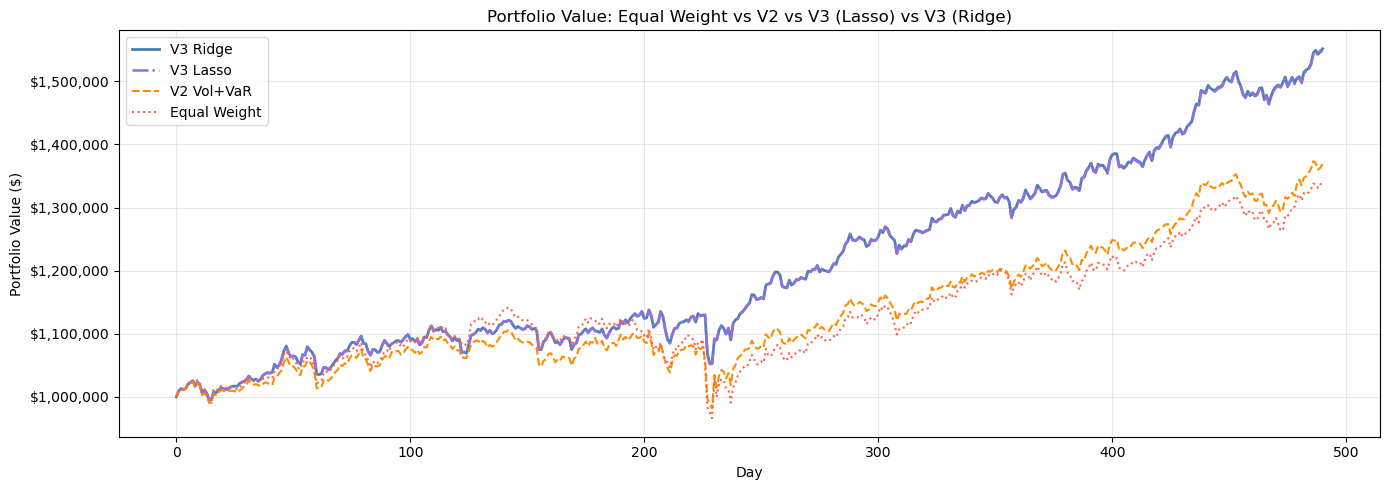

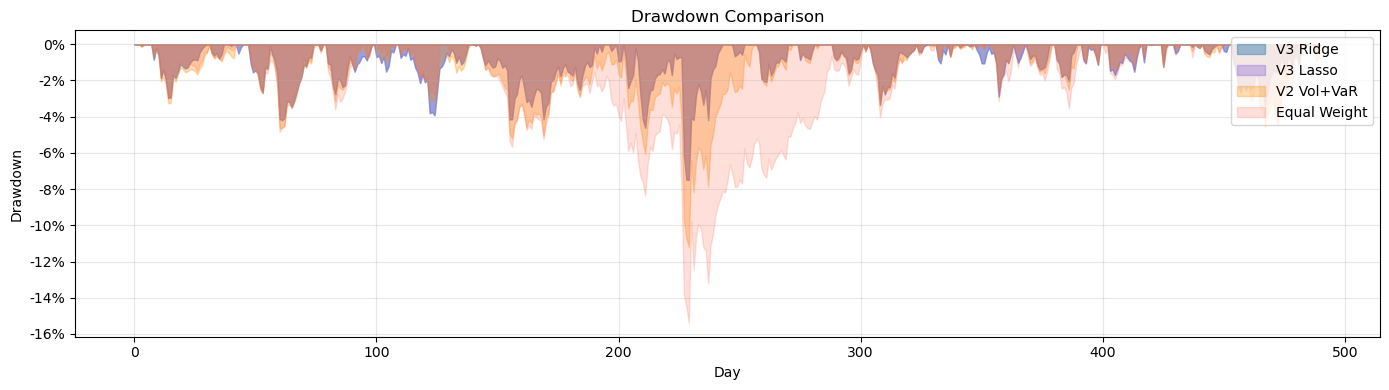

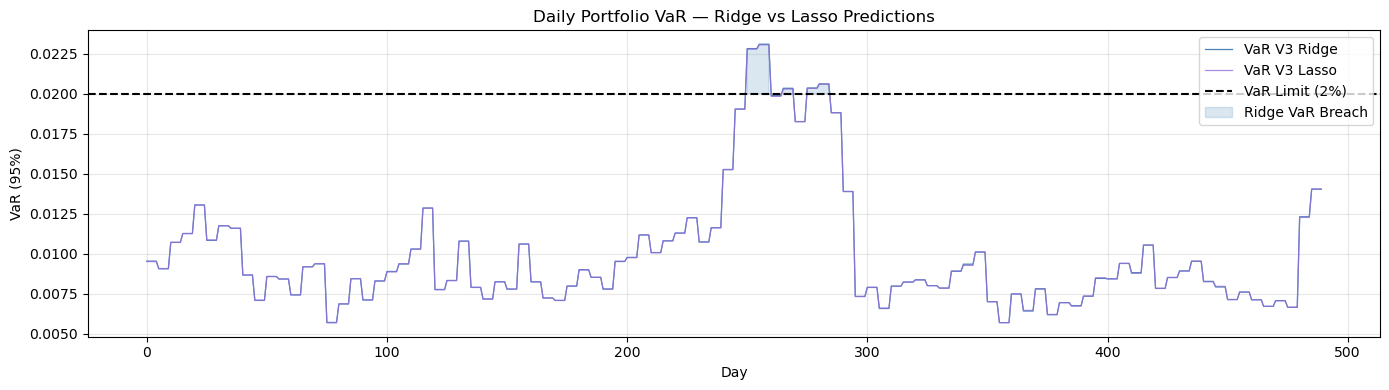

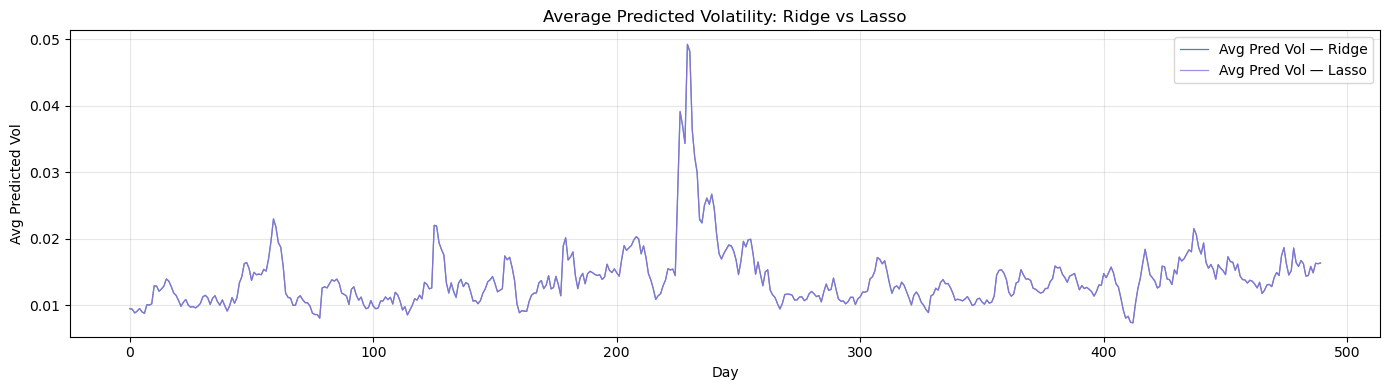

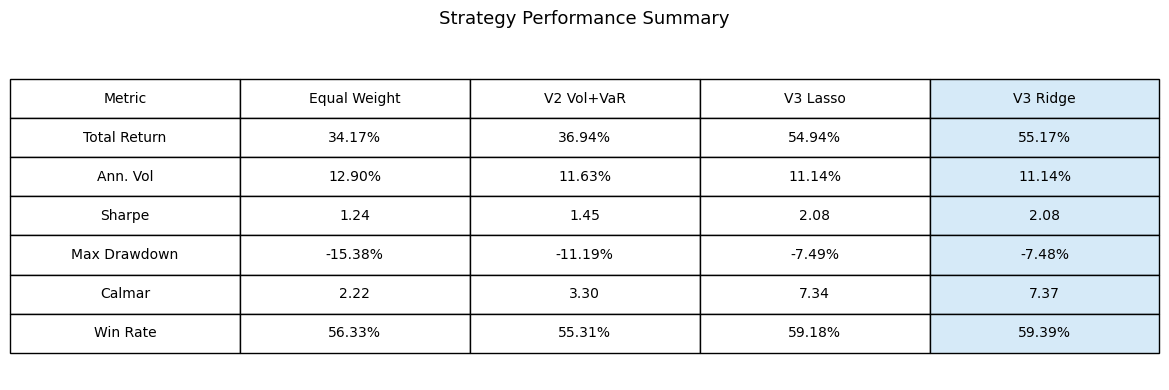

In [319]:
# ============================================================
# PORTFOLIO BACKTEST — 4 Strategies Comparison
#   1. Equal Weight Benchmark
#   2. V2  — Vol-Inverse + VaR only         (uses best_final_pred)
#   3. V3 (Lasso) — + Momentum + Regime     (uses Lasso predictions)
#   4. V3 (Ridge) — + Momentum + Regime     (uses Ridge predictions)
#
# Paste this as a new cell block AFTER your Part C evaluation.
# Requires:  df_model, split_idx, features, final_predictions,
#            X_train, X_test, y_train, y_test
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. Parameters (same as your original block)
# -------------------------------------------
CAPITAL           = 1_000_000
VAR_CONFIDENCE    = 0.95
VAR_LIMIT         = 0.02
N_STOCKS          = 20
LOOKBACK          = 60
REBALANCE_FREQ    = 5
TRANSACTION_COST  = 0.001
MAX_SINGLE_WEIGHT = 0.20
MA_SHORT          = 20
MA_LONG           = 50
REGIME_WINDOW     = 20

# -------------------------------------------
# 2. Select diversified tickers (same logic)
# -------------------------------------------
train_tickers = set(df_model["ticker"].iloc[:split_idx].unique())
test_tickers  = set(df_model["ticker"].iloc[split_idx:].unique())
valid_tickers = list(train_tickers.intersection(test_tickers))

sector_map = {
    "Technology": ["AAPL","MSFT","GOOGL","NVDA","TXN","QCOM","IBM","INTU"],
    "Finance":    ["JPM","BAC","GS","MS","BLK","SCHW","IBKR"],
    "Healthcare": ["JNJ","UNH","PFE","MRK","ABT","ISRG","IDXX"],
    "Energy":     ["XOM","CVX","COP","PSX","EOG"],
    "Consumer":   ["MCD","PG","KO","WMT","COST","TGT","LOW"],
    "Industrial": ["HON","ITW","PWR","AJG","HUBB"],
    "Other":      ["IRM","VRSN","VRSK","ICE","IEX"],
}

selected_tickers = []
for sector, tickers in sector_map.items():
    in_data = [t for t in tickers if t in valid_tickers][:3]
    selected_tickers.extend(in_data)
    print(f"  {sector:<15}: {in_data}")

if len(selected_tickers) < 10:
    selected_tickers = valid_tickers[:N_STOCKS]
else:
    selected_tickers = selected_tickers[:N_STOCKS]

print(f"\nFinal portfolio: {len(selected_tickers)} stocks")
print(selected_tickers)

# -------------------------------------------
# 3. Retrain Lasso & Ridge on train set,
#    produce test-set predictions
# -------------------------------------------
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Lasso model (same params as Part B)
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Lasso(alpha=0.00001, max_iter=10000))
])
lasso_pipe.fit(X_train, y_train)
lasso_test_pred = lasso_pipe.predict(X_test)

# Ridge model (same params as Part B)
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_train)
ridge_test_pred = ridge_pipe.predict(X_test)

print("\nLasso test predictions — min/max:",
      lasso_test_pred.min().round(6), lasso_test_pred.max().round(6))
print("Ridge test predictions — min/max:",
      ridge_test_pred.min().round(6), ridge_test_pred.max().round(6))

# -------------------------------------------
# 4. Build pred_df variants for each model
# -------------------------------------------
test_slice = df_model.iloc[split_idx:].reset_index(drop=True)

def make_pred_df(pred_array, test_slice, selected_tickers):
    """Build a prediction dataframe for backtesting."""
    pdf = pd.DataFrame({
        "ticker":   test_slice["ticker"].values,
        "date":     test_slice["Date"].values,
        "pred_vol": pred_array,
        "return_1": test_slice["return_1"].values,
        "close":    test_slice["close"].values,
    })
    pdf = pdf[pdf["ticker"].isin(selected_tickers)].copy()
    pdf = pdf.sort_values("date").reset_index(drop=True)
    return pdf

# Use best_final_pred for V2 (matches original notebook)
pred_df_best  = make_pred_df(best_final_pred, test_slice, selected_tickers)
pred_df_lasso = make_pred_df(lasso_test_pred, test_slice, selected_tickers)
pred_df_ridge = make_pred_df(ridge_test_pred, test_slice, selected_tickers)

dates = sorted(pred_df_best["date"].unique())
print(f"\nTest period : {dates[0]} → {dates[-1]}")
print(f"Trading days: {len(dates)}")

# -------------------------------------------
# 5. Precompute moving averages (from close prices)
# -------------------------------------------
ma_short_dict = {}
ma_long_dict  = {}

for ticker in selected_tickers:
    prices = pred_df_best[pred_df_best["ticker"] == ticker].set_index("date")["close"]
    ma_short_dict[ticker] = prices.rolling(MA_SHORT).mean().to_dict()
    ma_long_dict[ticker]  = prices.rolling(MA_LONG).mean().to_dict()

print("Moving averages precomputed.")

# -------------------------------------------
# 6. Helper functions
# -------------------------------------------
def historical_var(returns, confidence=0.95):
    if len(returns) < 5:
        return 0.02
    return float(abs(np.percentile(returns, (1 - confidence) * 100)))

def portfolio_var(weights, returns_matrix, confidence=0.95):
    if returns_matrix.shape[0] < 5:
        return 0.02
    port_returns = returns_matrix.dot(weights)
    return historical_var(port_returns, confidence)

def get_momentum_multiplier(ticker, date, price, ma_short_dict, ma_long_dict):
    ma_s = ma_short_dict.get(ticker, {}).get(date, None)
    ma_l = ma_long_dict.get(ticker,  {}).get(date, None)
    if ma_s is None or ma_l is None:
        return 1.0
    if price > ma_s > ma_l:
        return 1.0
    elif price > ma_l:
        return 0.7
    else:
        return 0.2

def get_regime_scale(vol_history, current_vol, window=REGIME_WINDOW):
    if len(vol_history) < window:
        return 1.0
    recent_median = np.median(vol_history[-window:])
    if current_vol > recent_median * 1.5:
        return 0.5
    elif current_vol < recent_median * 0.7:
        return 1.2
    else:
        return 1.0

# -------------------------------------------
# 7. Core portfolio strategies
# -------------------------------------------
def equal_weight_portfolio(pred_df, dates, tickers,
                            capital=CAPITAL, lookback=LOOKBACK):
    """Simple equal-weight benchmark — no vol forecast used."""
    portfolio_values = [capital]
    for date in dates[lookback:]:
        today     = pred_df[pred_df["date"] == date]
        available = today[today["ticker"].isin(tickers)]
        if len(available) < 3:
            portfolio_values.append(portfolio_values[-1])
            continue
        n           = len(available)
        weights     = np.ones(n) / n
        port_return = float(np.dot(weights, available["return_1"].values))
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    return pd.Series(portfolio_values)


def vol_var_portfolio(pred_df, dates, tickers,
                      capital=CAPITAL,
                      var_limit=VAR_LIMIT,
                      confidence=VAR_CONFIDENCE,
                      lookback=LOOKBACK,
                      rebalance_freq=REBALANCE_FREQ,
                      transaction_cost=TRANSACTION_COST,
                      max_weight=MAX_SINGLE_WEIGHT,
                      use_momentum=False,
                      use_regime=False):
    """
    Inverse-vol portfolio with optional VaR cap, momentum filter,
    and regime scaling.

    V2  → use_momentum=False, use_regime=False
    V3  → use_momentum=True,  use_regime=True
    """
    portfolio_values = [capital]
    daily_log        = []
    prev_weights     = None
    current_weights  = None
    current_tickers  = None
    vol_history      = []

    for i, date in enumerate(dates[lookback:], start=lookback):
        today         = pred_df[pred_df["date"] == date]
        available     = today[today["ticker"].isin(tickers)].copy()

        if len(available) < 3:
            portfolio_values.append(portfolio_values[-1])
            continue

        tickers_today = available["ticker"].values
        pred_vols     = available["pred_vol"].values
        today_returns = available["return_1"].values
        prices_today  = available["close"].values

        rebalance_today = (i % rebalance_freq == 0) or (current_weights is None)

        if rebalance_today:
            # Step 1 — Inverse vol weights
            inv_vol     = 1.0 / np.maximum(pred_vols, 1e-6)
            raw_weights = inv_vol / inv_vol.sum()

            # Step 2 — Cap single stock
            raw_weights = np.minimum(raw_weights, max_weight)
            raw_weights = raw_weights / raw_weights.sum()

            # Step 3 — Momentum filter (V3 only)
            if use_momentum:
                momentum_mults = np.array([
                    get_momentum_multiplier(
                        ticker, date, prices_today[j],
                        ma_short_dict, ma_long_dict
                    )
                    for j, ticker in enumerate(tickers_today)
                ])
                raw_weights = raw_weights * momentum_mults
                if raw_weights.sum() > 0:
                    raw_weights = raw_weights / raw_weights.sum()

            # Step 4 — VaR constraint
            hist_dates = dates[i - lookback:i]
            hist_cols  = []
            for ticker in tickers_today:
                hist = pred_df[
                    (pred_df["ticker"] == ticker) &
                    (pred_df["date"].isin(hist_dates))
                ]["return_1"].values
                if len(hist) >= lookback:
                    hist_cols.append(hist[-lookback:])
                elif len(hist) > 0:
                    hist_cols.append(np.pad(hist, (lookback - len(hist), 0)))
                else:
                    hist_cols.append(np.zeros(lookback))

            hist_matrix = np.column_stack(hist_cols)
            port_v      = portfolio_var(raw_weights, hist_matrix, confidence)

            if port_v > var_limit:
                scale         = var_limit / port_v
                final_weights = raw_weights * scale
            else:
                final_weights = raw_weights.copy()

            # Step 5 — Vol regime scale (V3 only)
            avg_vol = pred_vols.mean()
            vol_history.append(avg_vol)
            if use_regime:
                regime_scale  = get_regime_scale(vol_history, avg_vol)
                final_weights = final_weights * regime_scale

            # Step 6 — Transaction cost
            if prev_weights is not None and current_tickers is not None:
                prev_dict  = dict(zip(current_tickers, prev_weights))
                curr_dict  = dict(zip(tickers_today,   final_weights))
                all_t      = set(list(prev_dict.keys()) + list(curr_dict.keys()))
                turnover   = sum(abs(curr_dict.get(t, 0) - prev_dict.get(t, 0))
                                 for t in all_t)
                trade_cost = turnover * transaction_cost
            else:
                trade_cost = 0.0

            prev_weights    = final_weights.copy()
            current_weights = final_weights.copy()
            current_tickers = tickers_today.copy()
            port_v_final    = port_v

        else:
            # Hold — no rebalance
            if current_weights is not None and current_tickers is not None:
                weight_dict   = dict(zip(current_tickers, current_weights))
                final_weights = np.array([weight_dict.get(t, 0)
                                          for t in tickers_today])
                norm_sum      = final_weights.sum()
                final_weights = (final_weights / norm_sum
                                 if norm_sum > 0 else final_weights)
            else:
                final_weights = np.ones(len(tickers_today)) / len(tickers_today)

            avg_vol = pred_vols.mean()
            vol_history.append(avg_vol)
            trade_cost   = 0.0
            port_v_final = daily_log[-1]["port_var"] if daily_log else var_limit

        # Portfolio daily return
        n           = min(len(final_weights), len(today_returns))
        port_return = float(np.dot(final_weights[:n], today_returns[:n])) - trade_cost
        cash_weight = max(1.0 - final_weights.sum(), 0.0)
        new_value   = portfolio_values[-1] * (1 + port_return)
        portfolio_values.append(new_value)

        daily_log.append({
            "date":        date,
            "port_var":    port_v_final,
            "cash_weight": cash_weight,
            "trade_cost":  trade_cost,
            "rebalanced":  rebalance_today,
            "n_stocks":    len(tickers_today),
            "port_return": port_return,
            "avg_pred_vol": avg_vol,
        })

    return pd.Series(portfolio_values), pd.DataFrame(daily_log)


# -------------------------------------------
# 8. Evaluation helper
# -------------------------------------------
def evaluate_portfolio(cum_values, name, capital=CAPITAL):
    returns  = cum_values.pct_change().dropna().reset_index(drop=True)
    total    = (cum_values.iloc[-1] - capital) / capital
    sharpe   = (returns.mean() / returns.std()) * np.sqrt(252)
    max_dd   = (cum_values / cum_values.cummax() - 1).min()
    ann_vol  = returns.std() * np.sqrt(252)
    calmar   = total / abs(max_dd) if max_dd != 0 else 0
    win_rate = (returns > 0).sum() / len(returns)

    print(f"\n{'='*5} {name} {'='*5}")
    print(f"Total Return:    {total:.2%}")
    print(f"Annualized Vol:  {ann_vol:.2%}")
    print(f"Sharpe Ratio:    {sharpe:.2f}")
    print(f"Max Drawdown:    {max_dd:.2%}")
    print(f"Calmar Ratio:    {calmar:.2f}")
    print(f"Win Rate:        {win_rate:.2%}")

    return {
        "name": name, "total": total, "sharpe": sharpe,
        "max_dd": max_dd, "ann_vol": ann_vol, "calmar": calmar,
        "win_rate": win_rate
    }


# -------------------------------------------
# 9. Run all 4 strategies
# -------------------------------------------
print("\n--- Running Equal Weight ---")
cum_eq = equal_weight_portfolio(pred_df_best, dates, selected_tickers)

print("--- Running V2 (Vol+VaR only, best model preds) ---")
cum_v2, log_v2 = vol_var_portfolio(
    pred_df_best, dates, selected_tickers,
    use_momentum=False, use_regime=False
)

print("--- Running V3 with Lasso predictions ---")
cum_v3_lasso, log_v3_lasso = vol_var_portfolio(
    pred_df_lasso, dates, selected_tickers,
    use_momentum=True, use_regime=True
)

print("--- Running V3 with Ridge predictions ---")
cum_v3_ridge, log_v3_ridge = vol_var_portfolio(
    pred_df_ridge, dates, selected_tickers,
    use_momentum=True, use_regime=True
)

# -------------------------------------------
# 10. Evaluate
# -------------------------------------------
res_eq        = evaluate_portfolio(cum_eq,        "Equal Weight")
res_v2        = evaluate_portfolio(cum_v2,        "V2 Vol+VaR")
res_v3_lasso  = evaluate_portfolio(cum_v3_lasso,  "V3 Lasso")
res_v3_ridge  = evaluate_portfolio(cum_v3_ridge,  "V3 Ridge")

# Transaction cost summary
for label, log in [("V2", log_v2), ("V3 Lasso", log_v3_lasso), ("V3 Ridge", log_v3_ridge)]:
    print(f"\n--- {label} Stats ---")
    print(f"  Rebalance days:         {log['rebalanced'].sum()}")
    print(f"  Total transaction cost: {log['trade_cost'].sum():.4f}")
    print(f"  Days VaR > limit:       {(log['port_var'] > VAR_LIMIT).sum()}")
    print(f"  Avg cash allocation:    {log['cash_weight'].mean():.2%}")

# -------------------------------------------
# 11. Plots
# -------------------------------------------
n = len(cum_v3_lasso)

# Align all series to same length
cum_eq_r       = cum_eq.reset_index(drop=True)[:n]
cum_v2_r       = cum_v2.reset_index(drop=True)[:n]
cum_v3_lasso_r = cum_v3_lasso.reset_index(drop=True)[:n]
cum_v3_ridge_r = cum_v3_ridge.reset_index(drop=True)[:n]

# --- Plot 1: Portfolio Value ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cum_v3_ridge_r.values, label="V3 Ridge",     color="steelblue",    linewidth=2)
ax.plot(cum_v3_lasso_r.values, label="V3 Lasso",     color="mediumpurple", linewidth=1.8, linestyle="-.")
ax.plot(cum_v2_r.values,       label="V2 Vol+VaR",   color="darkorange",   linewidth=1.5, linestyle="--")
ax.plot(cum_eq_r.values,       label="Equal Weight", color="tomato",       linewidth=1.5, linestyle=":")
ax.set_title("Portfolio Value: Equal Weight vs V2 vs V3 (Lasso) vs V3 (Ridge)")
ax.set_xlabel("Day")
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Drawdown ---
dd_eq    = (cum_eq_r       / cum_eq_r.cummax()       - 1)
dd_v2    = (cum_v2_r       / cum_v2_r.cummax()       - 1)
dd_lasso = (cum_v3_lasso_r / cum_v3_lasso_r.cummax() - 1)
dd_ridge = (cum_v3_ridge_r / cum_v3_ridge_r.cummax() - 1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(n), dd_ridge.values, alpha=0.5, color="steelblue",    label="V3 Ridge")
ax.fill_between(range(n), dd_lasso.values, alpha=0.4, color="mediumpurple", label="V3 Lasso")
ax.fill_between(range(n), dd_v2.values,    alpha=0.3, color="darkorange",   label="V2 Vol+VaR")
ax.fill_between(range(n), dd_eq.values,    alpha=0.2, color="tomato",       label="Equal Weight")
ax.set_title("Drawdown Comparison")
ax.set_xlabel("Day")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 3: Daily VaR (Ridge vs Lasso) ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(log_v3_ridge["port_var"].values, color="steelblue",    linewidth=0.9, label="VaR V3 Ridge")
ax.plot(log_v3_lasso["port_var"].values, color="mediumpurple", linewidth=0.9, label="VaR V3 Lasso", alpha=0.8)
ax.axhline(VAR_LIMIT, color="black", linestyle="--", linewidth=1.5,
           label=f"VaR Limit ({VAR_LIMIT:.0%})")
ax.fill_between(range(len(log_v3_ridge)),
                log_v3_ridge["port_var"].values, VAR_LIMIT,
                where=log_v3_ridge["port_var"].values > VAR_LIMIT,
                alpha=0.2, color="steelblue", label="Ridge VaR Breach")
ax.set_title("Daily Portfolio VaR — Ridge vs Lasso Predictions")
ax.set_xlabel("Day")
ax.set_ylabel("VaR (95%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 4: Predicted Vol comparison (Ridge vs Lasso) ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(log_v3_ridge["avg_pred_vol"].values, color="steelblue",    linewidth=0.9, label="Avg Pred Vol — Ridge")
ax.plot(log_v3_lasso["avg_pred_vol"].values, color="mediumpurple", linewidth=0.9, label="Avg Pred Vol — Lasso", alpha=0.8)
ax.set_title("Average Predicted Volatility: Ridge vs Lasso")
ax.set_xlabel("Day")
ax.set_ylabel("Avg Predicted Vol")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 5: Summary table ---
metrics = ["Total Return", "Ann. Vol", "Sharpe", "Max Drawdown", "Calmar", "Win Rate"]
rows = []
for res in [res_eq, res_v2, res_v3_lasso, res_v3_ridge]:
    rows.append([
        f"{res['total']:.2%}",
        f"{res['ann_vol']:.2%}",
        f"{res['sharpe']:.2f}",
        f"{res['max_dd']:.2%}",
        f"{res['calmar']:.2f}",
        f"{res['win_rate']:.2%}",
    ])

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")
table = ax.table(
    cellText  = list(zip(metrics, *rows)),
    colLabels = ["Metric", "Equal Weight", "V2 Vol+VaR", "V3 Lasso", "V3 Ridge"],
    cellLoc   = "center",
    loc       = "center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 2.2)

# Highlight Ridge column (col index 4)
for row_idx in range(len(metrics) + 1):
    cell = table[row_idx, 4]
    cell.set_facecolor("#d6eaf8")

ax.set_title("Strategy Performance Summary", fontsize=13, pad=20)
plt.tight_layout()
plt.show()